In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Agpt4Yq9wRwGYtrunFFd")
project = rf.workspace("dl-bdqrj").project("my-first-project-0f0ms")
version = project.version(2)
dataset = version.download("folder")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-big


Extracting Dataset Version Zip to My-First-Project-2 in folder:: 100%|██████████| 77218/77218 [00:07<00:00, 10435.51it/s]


In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# =====================================
# IMPORTANT: DISABLE MIXED PRECISION (to avoid loading errors)
# =====================================
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('float32')

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [12]:
train_dir = "/kaggle/working/My-First-Project-2/train"
val_dir   = "/kaggle/working/My-First-Project-2/valid"
test_dir  = "/kaggle/working/My-First-Project-2/test"

img_height, img_width = 224, 224
batch_size = 32
epochs = 15

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    shear_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_ds.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)

Found 65148 images belonging to 15 classes.
Found 8046 images belonging to 15 classes.
Found 4022 images belonging to 15 classes.
Classes: ['Bear', 'Buffalo', 'Cheetah', 'Deer', 'Elephant', 'Fox', 'Hyena', 'Jaguar', 'Leopard', 'Lion', 'Monkey', 'Rhino', 'Tiger', 'Wolf', 'Zebra']


In [14]:
base_model = VGG19(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# 🔥 Functional API (fixes your error)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,296,783 (77.43 MB)

 Trainable params: 7,350,799 (28.04 MB)

 Non-trainable params: 12,945,984 (49.39 MB)

In [16]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),

    ModelCheckpoint(
        "best_vgg19_model.keras",   # 🔥 NEW FORMAT
        monitor='val_accuracy',
        save_best_only=True
    )
]


In [17]:
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

end_time = time.time()

print(f"\n⏱ Training Time: {(end_time - start_time)/60:.2f} minutes")


Epoch 1/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 990s 474ms/step - accuracy: 0.5364 - loss: 1.4428 - val_accuracy: 0.8102 - val_loss: 0.6066
Epoch 2/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 932s 458ms/step - accuracy: 0.7809 - loss: 0.6835 - val_accuracy: 0.8711 - val_loss: 0.4408
Epoch 3/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 940s 462ms/step - accuracy: 0.8339 - loss: 0.5283 - val_accuracy: 0.8748 - val_loss: 0.4161
Epoch 4/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 949s 466ms/step - accuracy: 0.8591 - loss: 0.4364 - val_accuracy: 0.9012 - val_loss: 0.3209
Epoch 5/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 940s 461ms/step - accuracy: 0.8795 - loss: 0.3771 - val_accuracy: 0.9115 - val_loss: 0.3166
Epoch 6/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 937s 460ms/step - accuracy: 0.8915 - loss: 0.3419 - val_accuracy: 0.9171 - val_loss: 0.2714
Epoch 7/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 946s 464ms/step - accuracy: 0.9032 - loss: 0.3041 - val_accuracy: 0.9119 - val_loss: 0.2989
Epoch 8/15
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 944s 464ms/step - ac

In [18]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

126/126 ━━━━━━━━━━━━━━━━━━━━ 43s 341ms/step - accuracy: 0.9244 - loss: 0.2607

✅ Test Accuracy: 93.16%


In [19]:
model.save("vgg19_model_final.keras")
print("✅ Model saved (SAFE FORMAT)")

✅ Model saved (SAFE FORMAT)


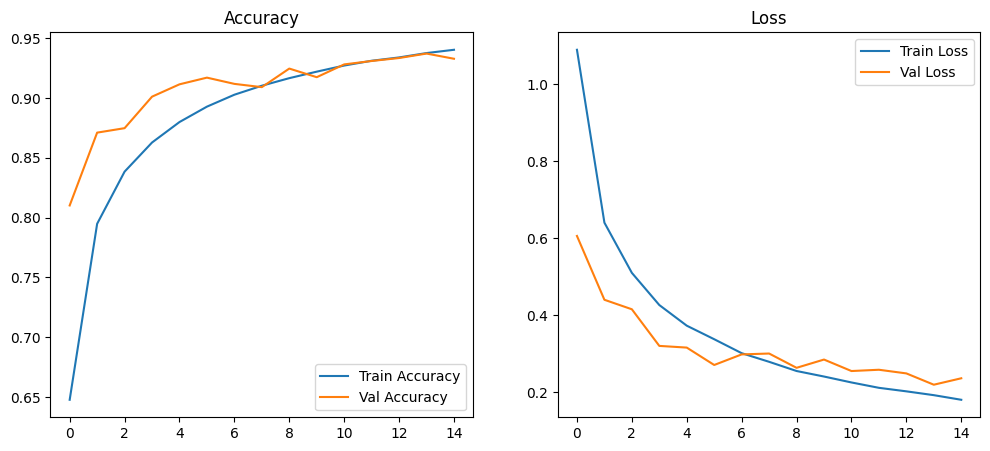

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
#plt.plot(test_acc_line, linestyle='--', label="Test Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
#plt.plot(test_loss_line, linestyle='--', label="Test Loss")
plt.legend()
plt.title("Loss")

plt.show()

126/126 ━━━━━━━━━━━━━━━━━━━━ 32s 249ms/step

Classification Report:

              precision    recall  f1-score   support

        Bear       0.97      0.93      0.94       241
     Buffalo       0.91      0.96      0.93       223
     Cheetah       0.96      0.89      0.92       350
        Deer       0.91      0.95      0.93       200
    Elephant       0.94      0.93      0.93       369
         Fox       0.86      0.92      0.89       219
       Hyena       0.96      0.91      0.93       256
      Jaguar       0.89      0.86      0.88       157
     Leopard       0.87      0.92      0.89       234
        Lion       0.90      0.96      0.93       563
      Monkey       0.94      0.97      0.96       135
       Rhino       0.96      0.91      0.94       222
       Tiger       0.98      0.93      0.96       495
        Wolf       0.98      0.93      0.96       148
       Zebra       0.95      1.00      0.97       210

    accuracy                           0.93      4022
   macro av

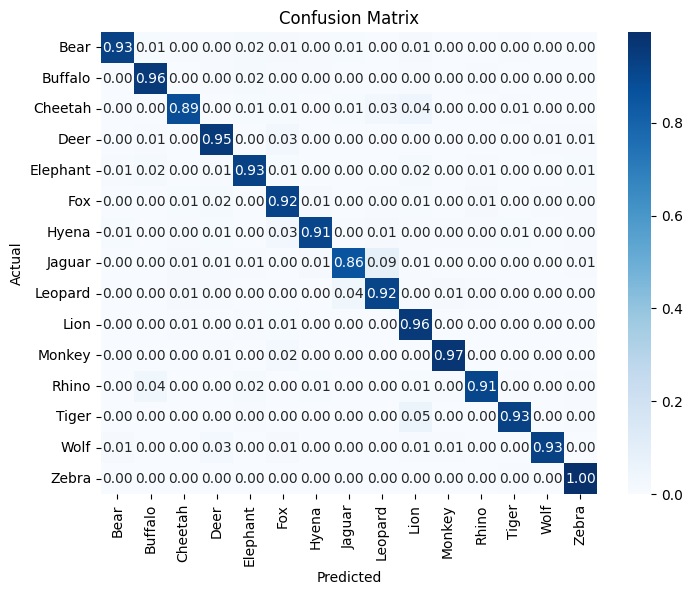

In [21]:
test_ds.reset()

y_true = test_ds.classes
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🦁 Predicted Animal: Elephant
🔍 Confidence: 100.00%
⏱ Prediction Time: 2.144053 seconds


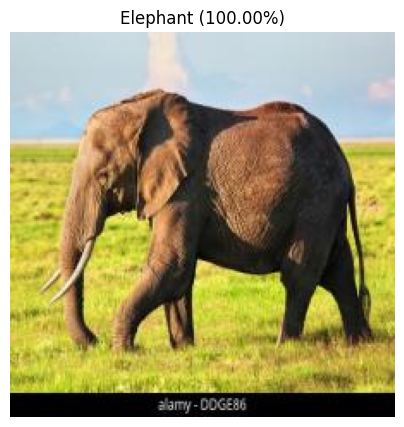

In [23]:
image_path = "/kaggle/working/My-First-Project-2/test/Elephant/day_1014_Elephant_921_jpg.rf.cdc1c319c9030b1a250f7f899dcf6ac9.jpg"

img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

start_time = time.time()
prediction = model.predict(img_array)
end_time = time.time()

prediction_time = end_time - start_time

pred_idx = np.argmax(prediction)
confidence = np.max(prediction) * 100
predicted_class = class_names[pred_idx]

print(f"\n🦁 Predicted Animal: {predicted_class}")
print(f"🔍 Confidence: {confidence:.2f}%")
print(f"⏱ Prediction Time: {prediction_time:.6f} seconds")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

🦁 Predicted Animal: Tiger
🔍 Confidence: 100.00%
⏱ Prediction Time: 0.100861 seconds


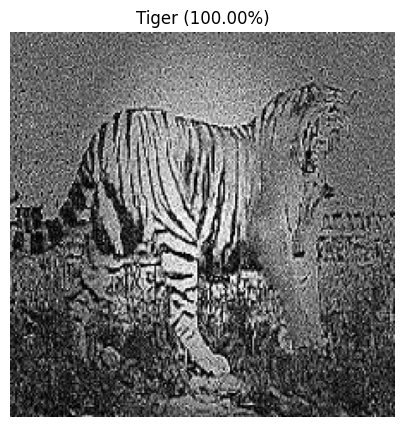

In [24]:
image_path = "/kaggle/working/My-First-Project-2/test/Tiger/night_1451_004049_jpg.rf.2a5b1ec644656b5e5780d2fdd06806b7.jpg"

img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

start_time = time.time()
prediction = model.predict(img_array)
end_time = time.time()

prediction_time = end_time - start_time

pred_idx = np.argmax(prediction)
confidence = np.max(prediction) * 100
predicted_class = class_names[pred_idx]

print(f"\n🦁 Predicted Animal: {predicted_class}")
print(f"🔍 Confidence: {confidence:.2f}%")
print(f"⏱ Prediction Time: {prediction_time:.6f} seconds")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

🦁 Predicted Animal: Rhino
🔍 Confidence: 99.98%
⏱ Prediction Time: 0.097333 seconds


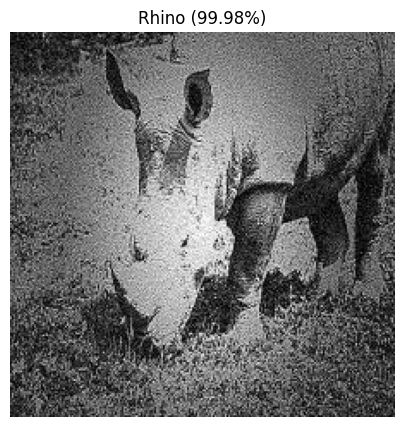

In [25]:
image_path = "/kaggle/working/My-First-Project-2/test/Rhino/night_573_Rhino_506_jpg.rf.b043c23f8e57d216b3df2ed8db28a56c.jpg"
img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

start_time = time.time()
prediction = model.predict(img_array)
end_time = time.time()

prediction_time = end_time - start_time

pred_idx = np.argmax(prediction)
confidence = np.max(prediction) * 100
predicted_class = class_names[pred_idx]

print(f"\n🦁 Predicted Animal: {predicted_class}")
print(f"🔍 Confidence: {confidence:.2f}%")
print(f"⏱ Prediction Time: {prediction_time:.6f} seconds")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

🦁 Predicted Animal: Elephant
🔍 Confidence: 98.09%
⏱ Prediction Time: 0.099571 seconds


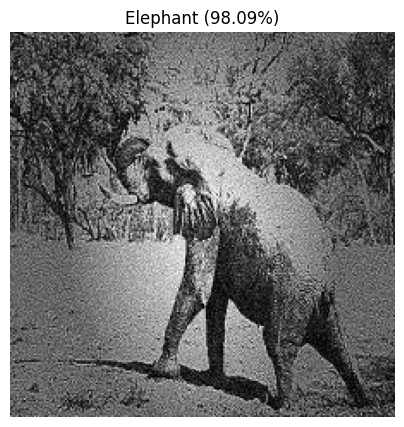

In [26]:
image_path = "/kaggle/working/My-First-Project-2/test/Elephant/night_239_Elephant_224_jpg.rf.4d046c83f1a28630691864334f986667.jpg"
img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

start_time = time.time()
prediction = model.predict(img_array)
end_time = time.time()

prediction_time = end_time - start_time

pred_idx = np.argmax(prediction)
confidence = np.max(prediction) * 100
predicted_class = class_names[pred_idx]

print(f"\n🦁 Predicted Animal: {predicted_class}")
print(f"🔍 Confidence: {confidence:.2f}%")
print(f"⏱ Prediction Time: {prediction_time:.6f} seconds")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()